In [1]:
import pandas as pd

df = pd.read_csv("../data/students_survey.csv")

In [2]:
df = df.rename(columns={'Psixoloji və sosial dəstək xidmətlərinin əlçatanlığını necə qiymətləndirirsiniz?': 'Support_access'}) 

In [3]:
cols = ['FinancialSatisfaction', 'Support_access']

df_cluster = df[cols].dropna()

In [53]:
financial_map = {
    "Heç razı deyiləm": 0,
    "Qismən razı deyiləm": 1,
    "Nə razıyam, nə deyiləm": 2,
    "Qismən razıyam": 3,
    "Xeyli razıyam": 4
}

support_map = {
    "Çox zəif": 0,
    "Zəif": 1,
    "Orta": 2,
    "Yaxşı": 3,
    "Əla": 4
}

"""supervisor_map = {
    "Heç razı deyiləm": 0,
    "Qismən razı deyiləm": 1,
    "Cavab verməkdə çətinlik çəkirəm": 2,
    "Qismən razıyam": 3,
    "Xeyli razıyam": 4
}"""
df_cluster['FinancialSatisfaction'] = df_cluster['FinancialSatisfaction'].map(financial_map)
df_cluster['Support_access'] = df_cluster['Support_access'].map(support_map)
#df_cluster['Supervisor_satisfaction'] = df_cluster['Supervisor_satisfaction'].map(supervisor_map)
df_cluster = df_cluster.dropna()

In [54]:
df_cluster.isna().any().any()

False

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

In [56]:
kmeans = KMeans(n_clusters=3, random_state=42)

NameError: name 'KMeans' is not defined

In [ ]:
labels = kmeans.fit_predict(X_scaled)

In [ ]:
df_cluster.shape

In [ ]:
X_scaled.shape

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print(score)

In [ ]:
df_cluster['Cluster'] = labels

In [ ]:
df_cluster.groupby('Cluster').mean()

In [ ]:
import seaborn as sns

sns.heatmap(
    df_cluster.groupby('Cluster').mean(),
    annot=True
)

plt.title("Cluster Profiles")
plt.show()

In [ ]:
sns.countplot(
    x='FinanciaSatisfaction',
    hue='Cluster',
    data=df_cluster
)
plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Select variables
df_reg = df[[
    'FinancialSatisfaction',
    'Support_access',
    'Supervisor_satisfaction',
    'Supervisor_meeting',
    'Supervisor_access',
    'Specialty'
]].copy()

# Clean text
df_reg = df_reg.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Encode ordinal variables (example)
df_reg['FinancialSatisfaction'] = df_reg['FinancialSatisfaction'].map(financial_map)
df_reg['Support_access'] = df_reg['Support_access'].map(support_map)

# Convert categorical (Specialty)
df_reg = pd.get_dummies(df_reg, columns=['Specialty'], drop_first=True)

# Drop missing
df_reg = df_reg.dropna()

# Define X and y
X = df_reg.drop(columns=['FinancialSatisfaction'])
y = df_reg['FinancialSatisfaction']

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

In [72]:
y = df['FinancialSatisfaction']
X = df.drop(columns=['FinancialSatisfaction'])

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_encoded = pd.get_dummies(X, drop_first=True)

In [75]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_encoded, y_encoded)

RandomForestClassifier(n_estimators=200, random_state=42)

In [76]:
import pandas as pd

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                                              feature  importance
1   Tədqiqat resurslarına və infrastrukturuna çıxı...    0.124819
0                                      Education year    0.087266
53                            Support_access_Çox zəif    0.051219
25                                     Form_Part time    0.040372
41                               Employement_Teaching    0.035701
55                Supervisor_meeting_Həftədə bir dəfə    0.034817
52                                Support_access_Zəif    0.031578
51                               Support_access_Yaxşı    0.030123
16                                Specialty_Philology    0.026733
70                            Supervisor_access_Yaxşı    0.026504


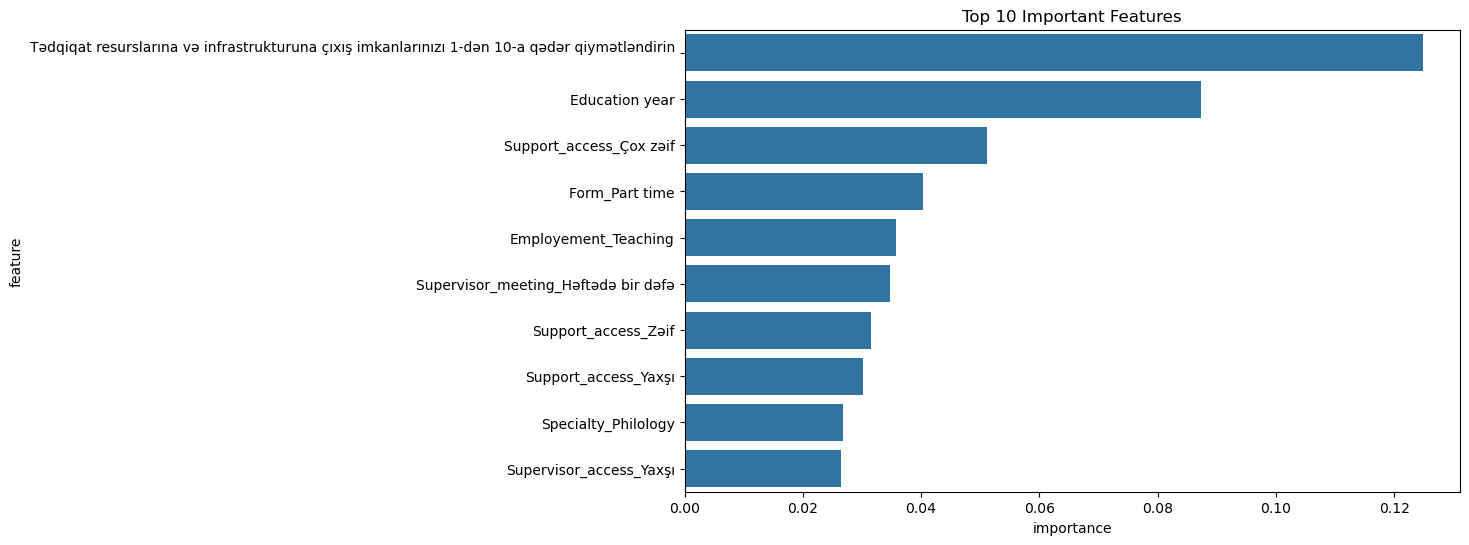

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()


In [78]:
y_pred = model.predict(X_encoded)

In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_encoded, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        83
           2       1.00      0.99      0.99        67
           3       1.00      1.00      1.00        73
           4       0.97      1.00      0.99        37
           5       1.00      1.00      1.00         8

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



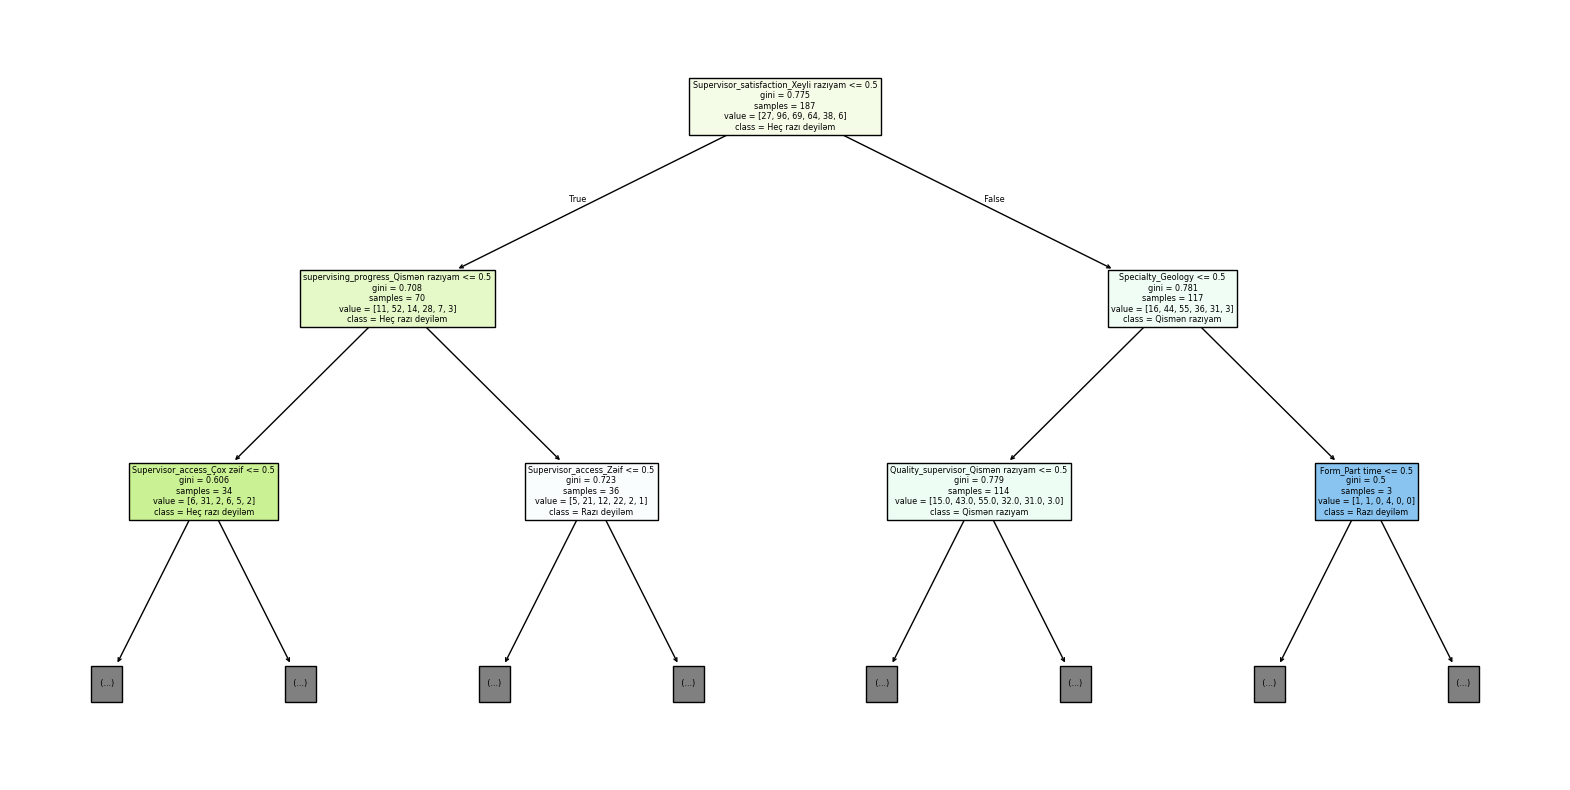

In [80]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select one tree from the forest
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X_encoded.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=2  # limit depth for readability
)

plt.show()

In [81]:
import shap

In [82]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_encoded)

(300, 77, 6)
                                              feature  importance
53                            Support_access_Çox zəif    0.033296
1   Tədqiqat resurslarına və infrastrukturuna çıxı...    0.029632
51                               Support_access_Yaxşı    0.018168
25                                     Form_Part time    0.016430
61                     Quality_supervisor_Tam razıyam    0.015109


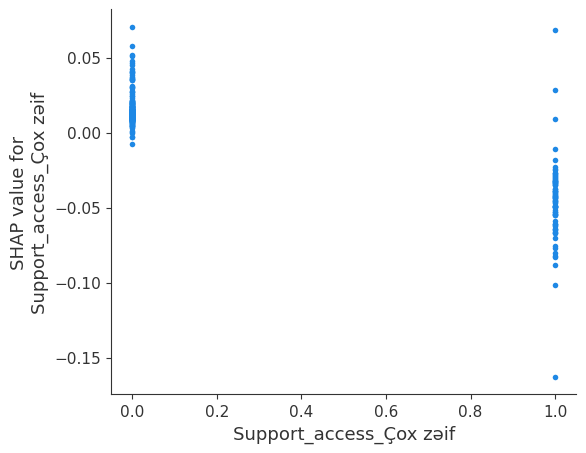

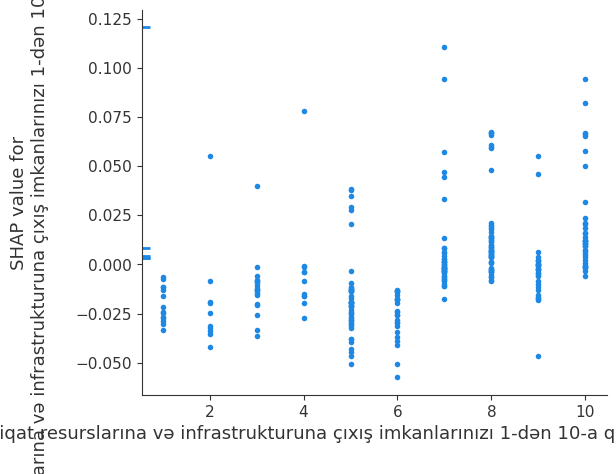

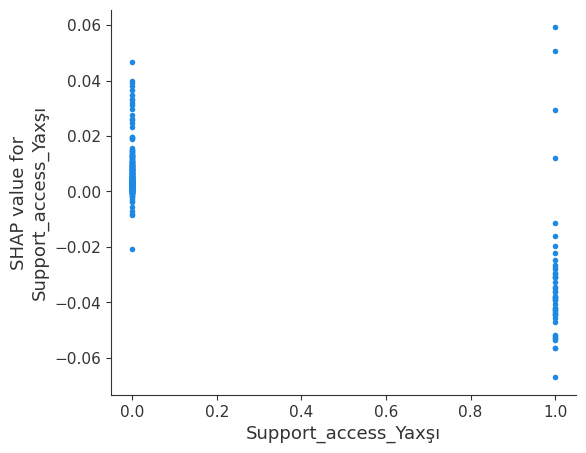

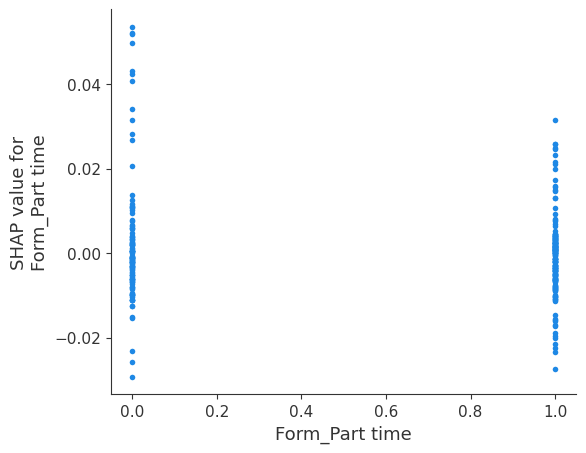

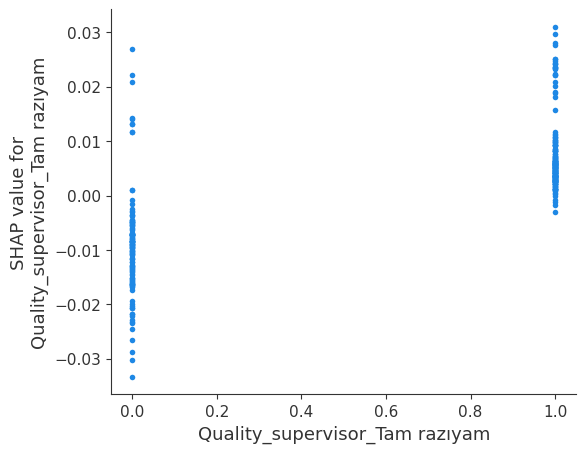

In [89]:
import numpy as np
import pandas as pd

# Check shape
print(shap_values.shape)

# Correct importance (NEW SHAP format)
shap_importance = np.abs(shap_values).mean(axis=(0, 2))

# Create DataFrame
shap_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False)

print(shap_df.head())

# Top features
top_features = shap_df['feature'].head(5)

# Plot
for col in top_features:
    shap.dependence_plot(
        col,
        shap_values[:, :, 0],   # choose one class for visualization
        X_encoded,
        interaction_index=None
    )

In [91]:
plt.figure(figsize=(14, 8))

shap.summary_plot(
    shap_values[:, :, 0],
    X_encoded,
    max_display=10,
    show=False
)

plt.savefig("../figures/shap_summary.png", bbox_inches='tight', dpi=300)
plt.close()

C:\ProgramData\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


In [71]:
features_to_plot = [
    "Education year",
    "Support_access_Çox zəif",
    "Support_access_Yaxşı"
]

for f in features_to_plot:
    shap.dependence_plot(f, shap_values[0], X_encoded)

IndexError: index 77 is out of bounds for axis 0 with size 77